<a href="https://colab.research.google.com/github/vrohithklh/ML_PRACTICALS/blob/main/ML_Exp3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import numpy as np

In [11]:
import pandas as pd

In [12]:
import matplotlib.pyplot as plt

In [13]:
from sklearn.linear_model import LinearRegression

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
from sklearn.preprocessing import StandardScaler

In [16]:
from sklearn.metrics import mean_squared_error

In [17]:
df = pd.read_csv('/content/placement_predict_50k Dataset.csv')

In [18]:
FEATURES = [
    "CGPA", "AttendancePercent", "Internships", "Projects",
    "Workshops", "Certifications", "Publications",
    "AptitudeTestScore", "SoftSkillsRating",
    "CodingTestScore", "MockInterviewScore", "ExtraCurricular",
]


In [19]:
TARGET = "Salary Package"

In [20]:
data = df[FEATURES + [TARGET]].copy()

In [21]:
data[FEATURES] = data[FEATURES].fillna(data[FEATURES].median())

In [22]:
X = data[FEATURES].values

In [23]:
y = data[TARGET].values.reshape(-1, 1)

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [25]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)


In [26]:
X_test_s = scaler.transform(X_test)

In [27]:
n_samples, n_features = X_train_s.shape

In [28]:
X_train_b = np.hstack([np.ones((n_samples, 1)), X_train_s])

In [29]:
X_test_b = np.hstack([np.ones((X_test_s.shape[0], 1)), X_test_s])

In [30]:
def compute_mse(X, y, theta):
    preds = X @ theta
    errors = preds - y
    return np.mean(errors ** 2)

In [31]:
def batch_gradient_descent(X, y, lr=0.05, n_epochs=500):
    m, n = X.shape
    theta = np.zeros((n, 1))
    loss_history = []
    for epoch in range(n_epochs):
        preds = X @ theta
        errors = preds - y
        gradient = (2 / m) * (X.T @ errors)
        theta -= lr * gradient
        loss_history.append(compute_mse(X, y, theta))
    return theta, loss_history

In [32]:
theta_gd, loss_history_gd = batch_gradient_descent(
    X_train_b, y_train, lr=0.05, n_epochs=500
)

In [33]:
rmse_gd = np.sqrt(compute_mse(X_test_b, y_test, theta_gd))
print(f"[Batch GD]      Test RMSE = {rmse_gd:.4f}")

[Batch GD]      Test RMSE = 4.4105


In [34]:
sk_model = LinearRegression()
sk_model.fit(X_train_s, y_train)

LinearRegression()

In [35]:
y_pred_sk = sk_model.predict(X_test_s)
rmse_sklearn = np.sqrt(mean_squared_error(y_test, y_pred_sk))

In [36]:
print(f"[sklearn LR]    Test RMSE = {rmse_sklearn:.4f}")
print(f"Difference (GD - sklearn) = {rmse_gd - rmse_sklearn:.6f}")

[sklearn LR]    Test RMSE = 4.4105
Difference (GD - sklearn) = 0.000000


In [37]:
def mini_batch_gradient_descent(X, y, lr=0.05, n_epochs=500, batch_size=256, seed=42):
    m, n = X.shape
    theta = np.zeros((n, 1))
    loss_history = []
    rng = np.random.default_rng(seed)

    for epoch in range(n_epochs):
        indices = rng.permutation(m)
        X_shuffled, y_shuffled = X[indices], y[indices]

        for start in range(0, m, batch_size):
            end = start + batch_size
            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]

            preds = X_batch @ theta
            errors = preds - y_batch
            gradient = (2 / X_batch.shape[0]) * (X_batch.T @ errors)
            theta -= lr * gradient

        loss_history.append(compute_mse(X, y, theta))
    return theta, loss_history

In [38]:
theta_mb, loss_history_mb = mini_batch_gradient_descent(
    X_train_b, y_train, lr=0.05, n_epochs=500, batch_size=256
)

In [39]:
rmse_mb = np.sqrt(compute_mse(X_test_b, y_test, theta_mb))
print(f"[Mini-batch GD] Test RMSE = {rmse_mb:.4f}")

[Mini-batch GD] Test RMSE = 4.4190


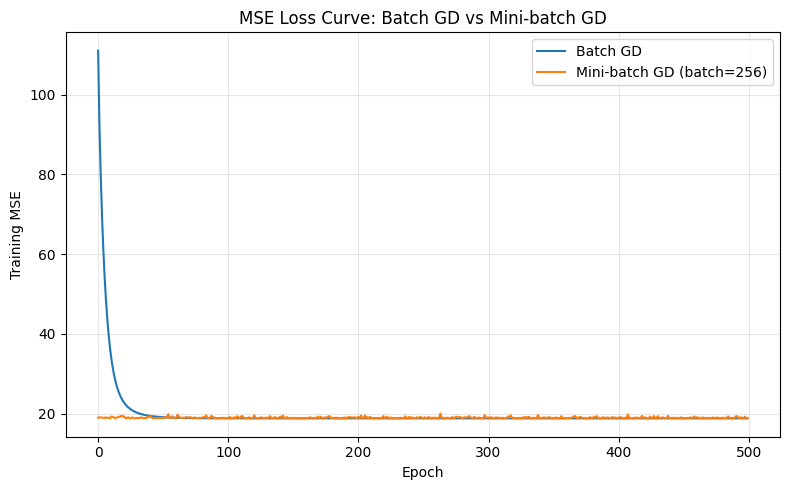

In [40]:
plt.figure(figsize=(8, 5))
plt.plot(loss_history_gd, label="Batch GD")
plt.plot(loss_history_mb, label="Mini-batch GD (batch=256)")
plt.xlabel("Epoch")
plt.ylabel("Training MSE")
plt.title("MSE Loss Curve: Batch GD vs Mini-batch GD")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=150)

In [41]:
print("\n=== RMSE Comparison ===")
print(f"{'Method':<20}{'Test RMSE':>12}")
print(f"{'Batch GD':<20}{rmse_gd:>12.4f}")
print(f"{'Mini-batch GD':<20}{rmse_mb:>12.4f}")
print(f"{'sklearn LinearReg':<20}{rmse_sklearn:>12.4f}")


=== RMSE Comparison ===
Method                 Test RMSE
Batch GD                  4.4105
Mini-batch GD             4.4190
sklearn LinearReg         4.4105
